In [92]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.problems import logistic_regression
from src.stopping_criterion import ObservableConvexCertificate
from src.optimizer import minimize

from sklearn.datasets import make_blobs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
def plot_clf(X, y, beta):
    x_line = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 1000)
    y_line = - beta[1] / beta[2] * x_line - beta[0] / beta[2]
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.scatter(X[:, 1], X[:, 2], c=y)
    ax.plot(x_line, y_line, linestyle='--', color='red')

    ax.set_ylim(X[:, 2].min() - 1, X[:, 2].max() + 1)

    return fig

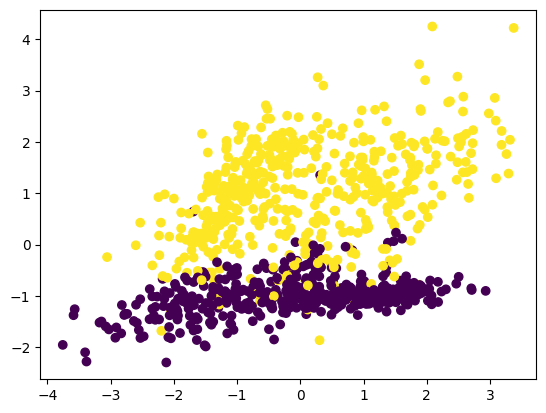

In [135]:
# X, y = make_blobs(n_samples=300, n_features=2, centers=2)
from sklearn.datasets import make_classification


X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_classes=2)
X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
plt.scatter(X[:, 1], X[:, 2], c=y)

In [142]:
# Rigid
eps = 1e-5
alpha = 0.05  # 95%
R = 5
sigma = 0.1

eta0 = 0.002
gamma = 0.3

fun, true_grad, stoch_gradd, proj = logistic_regression(X, y, R, batch_size=2)

beta0 = np.random.normal(0, 0.001, X.shape[1])

stop_criterion = ObservableConvexCertificate(R, sigma, alpha, eps)

report_interval = 1000
beta_avg_t, results = minimize(fun, true_grad, proj, beta0, eta0, gamma, stop_criterion, max_iter=500_000, verbose=True, report_interval=report_interval, true_grad=true_grad)

[Iter   1000]  F(x)= 0.61514 | F_avg(x)= 0.65246 | G_avg=  0.2183 | Cert=99.14132
[Iter   2000]  F(x)= 0.57564 | F_avg(x)= 0.63025 | G_avg= 0.20192 | Cert=60.92101
[Iter   3000]  F(x)= 0.54652 | F_avg(x)= 0.61304 | G_avg= 0.18951 | Cert=45.83482
[Iter   4000]  F(x)= 0.52329 | F_avg(x)= 0.59872 | G_avg=  0.1794 | Cert=37.45986
[Iter   5000]  F(x)= 0.50396 | F_avg(x)= 0.58637 | G_avg= 0.17085 | Cert=32.03442
[Iter   6000]  F(x)= 0.48746 | F_avg(x)= 0.57547 | G_avg= 0.16346 | Cert=28.19098
[Iter   7000]  F(x)= 0.47311 | F_avg(x)= 0.56571 | G_avg= 0.15695 | Cert=25.30388
[Iter   8000]  F(x)= 0.46044 | F_avg(x)= 0.55687 | G_avg= 0.15115 | Cert=23.04335
[Iter   9000]  F(x)= 0.44914 | F_avg(x)= 0.54877 | G_avg= 0.14593 | Cert=21.21781
[Iter  10000]  F(x)= 0.43896 | F_avg(x)= 0.54132 | G_avg=  0.1412 | Cert=19.70782
[Iter  11000]  F(x)= 0.42973 | F_avg(x)= 0.53440 | G_avg= 0.13687 | Cert=18.43474
[Iter  12000]  F(x)= 0.42130 | F_avg(x)= 0.52796 | G_avg=  0.1329 | Cert=17.34451
[Iter  13000]  F

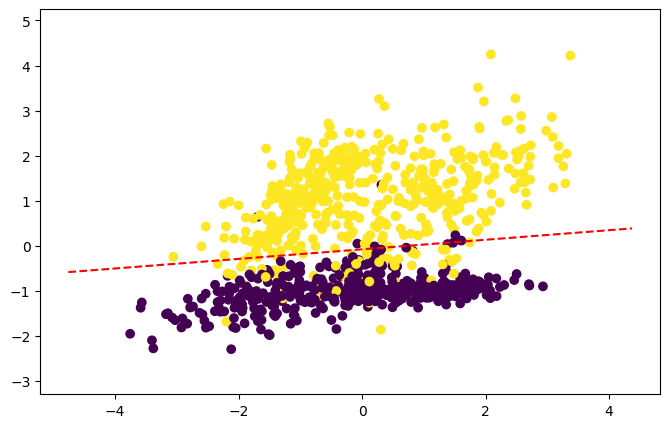

In [137]:
fig = plot_clf(X, y, beta_avg_t)